# Styling shapes and labels in spatialdata-plot

`color=` decides *what* colour a shape or label gets; a separate set of arguments decides *how* it is
drawn — how opaque the fill is, whether there is an outline, and how thick and what colour that outline
is. This tutorial walks through those styling knobs for `render_shapes` and `render_labels`. By the end
you should be able to:

- Control fill opacity with `fill_alpha`.
- Turn outlines on and style their width, colour, and opacity.
- Draw a double outline (outer + inner).
- Draw hollow shapes (outline only) and translucent label masks over an image.
- Trace segmentation boundaries with `outline` and `contour_px` on labels.

We use the synthetic `blobs` dataset throughout so the notebook stays small and reproducible.

## Setup

In [1]:
import spatialdata as sd
import spatialdata_plot  # noqa: F401  # registers the .pl accessor

sdata = sd.datasets.blobs()
sdata

SpatialData object
├── Images
│     ├── 'blobs_image': DataArray[cyx] (3, 512, 512)
│     └── 'blobs_multiscale_image': DataTree[cyx] (3, 512, 512), (3, 256, 256), (3, 128, 128)
├── Labels
│     ├── 'blobs_labels': DataArray[yx] (512, 512)
│     └── 'blobs_multiscale_labels': DataTree[yx] (512, 512), (256, 256), (128, 128)
├── Points
│     └── 'blobs_points': DataFrame with shape: (<Delayed>, 4) (2D points)
├── Shapes
│     ├── 'blobs_circles': GeoDataFrame shape: (5, 2) (2D shapes)
│     ├── 'blobs_multipolygons': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'blobs_polygons': GeoDataFrame shape: (5, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (26, 3)
with coordinate systems:
    ▸ 'global', with elements:
        blobs_image (Images), blobs_multiscale_image (Images), blobs_labels (Labels), blobs_multiscale_labels (Labels), blobs_points (Points), blobs_circles (Shapes), blobs_multipolygons (Shapes), blobs_polygons (Shapes)

## 1. Default shapes

The element names used below (`blobs_polygons`, `blobs_labels`, `blobs_image`) are the keys shown in
the `sdata` repr above. By default, shapes are drawn as filled patches with no outline. We start from
`blobs_polygons`.

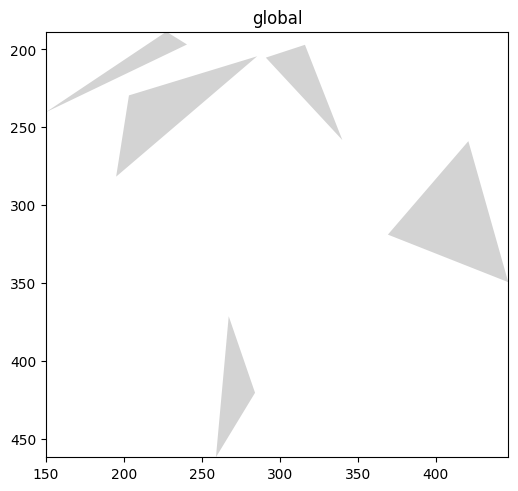

In [2]:
sdata.pl.render_shapes('blobs_polygons').pl.show()

## 2. Fill opacity — `fill_alpha`

`fill_alpha` sets how opaque the fill is, from `1.0` (solid) down to `0.0` (invisible). Lower it when
shapes overlap or sit on top of an image you still want to see.

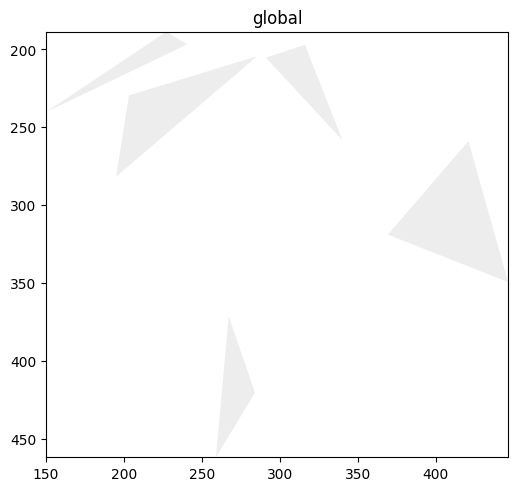

In [3]:
sdata.pl.render_shapes('blobs_polygons', fill_alpha=0.4).pl.show()

## 3. Outlines — the `outline` toggle

Pass `outline=True` to draw a border around each shape. Outlines are off by default; turning the toggle on gives every shape a crisp edge. (Leaving `outline=None` — the default — instead infers the border from whether you set any `outline_*` argument.)

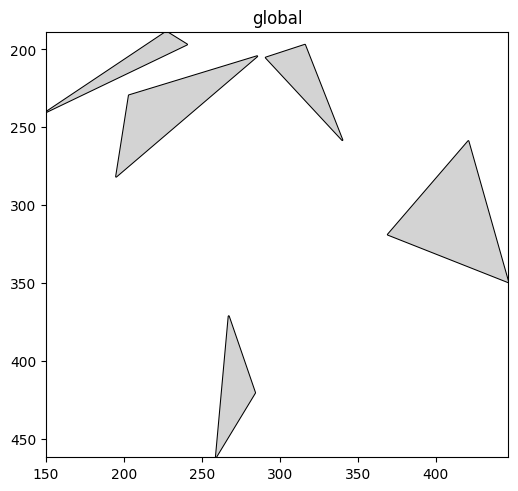

In [4]:
sdata.pl.render_shapes('blobs_polygons', outline=True).pl.show()

## 4. Styling the outline — width, colour, opacity

`outline_width`, `outline_color`, and `outline_alpha` control the border once `outline=True`.

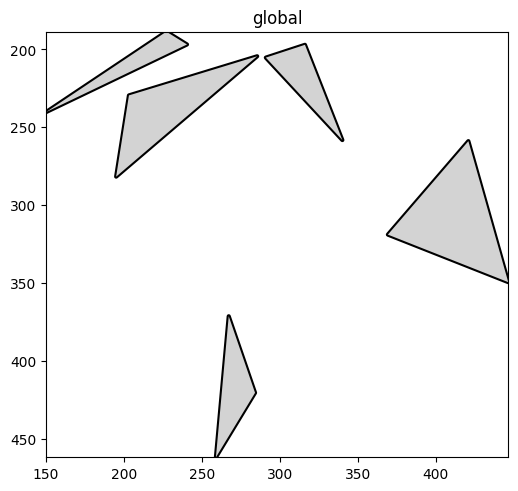

In [5]:
sdata.pl.render_shapes(
    'blobs_polygons',
    outline=True,
    outline_width=3.0,
    outline_color='black',
    outline_alpha=1.0,
).pl.show()

## 5. Two outlines — outer and inner

`outline_width`, `outline_color`, and `outline_alpha` each accept a **two-tuple** to draw two concentric borders — an outer band and an inner one — in a single call. Each tuple is `(outer, inner)`. Useful for a border that reads against both light and dark backgrounds, or simply to make an edge pop. Give any one of them a tuple and the others fall back to per-band defaults (widths `1.5`/`0.5`, colours `#000000`/`#ffffff` for outer/inner).

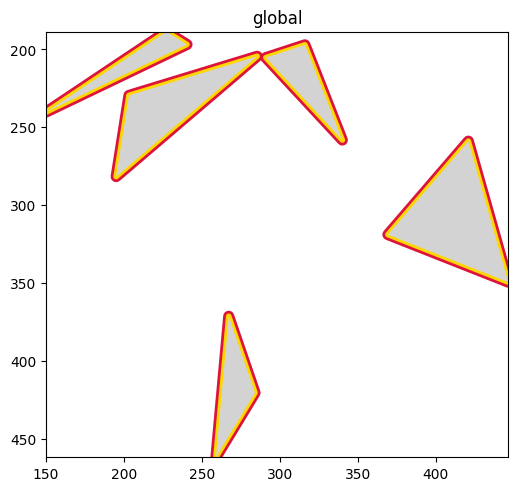

In [6]:
sdata.pl.render_shapes(
    'blobs_polygons',
    outline=True,
    outline_width=(8.0, 4.0),          # (outer, inner)
    outline_color=('crimson', 'gold'),
    outline_alpha=(1.0, 1.0),
).pl.show()

## 6. Hollow shapes — outline only

Combine a transparent fill (`fill_alpha=0.0`) with an outline to get outline-only shapes — useful for
marking regions of interest without hiding what is underneath.

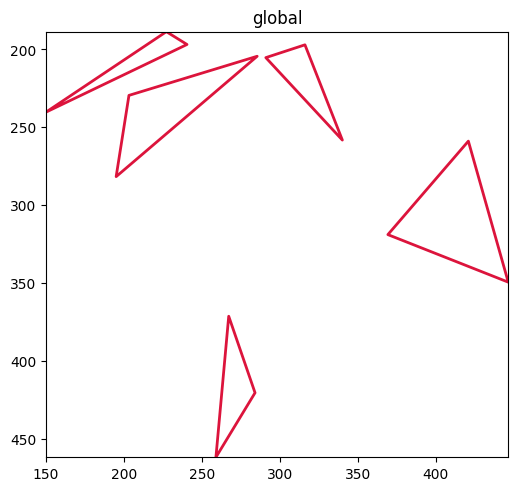

In [7]:
sdata.pl.render_shapes(
    'blobs_polygons',
    fill_alpha=0.0,
    outline=True,
    outline_width=2.0,
    outline_color='crimson',
).pl.show()

## 7. Resizing geometries — `scale`

`scale` multiplies each shape's size about its centroid: shrink to separate crowded shapes, or grow to
emphasise them. Here the polygons are drawn at 60% size with an outline.

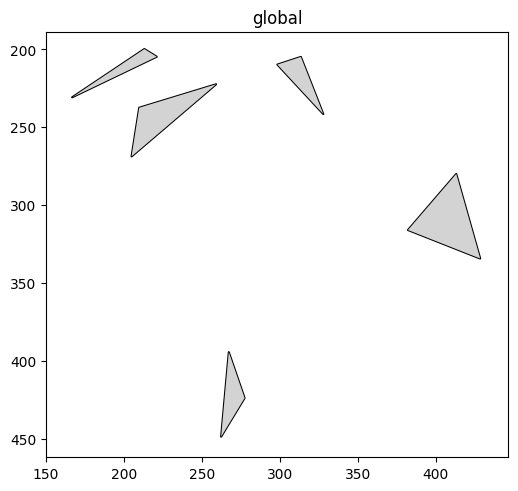

In [8]:
sdata.pl.render_shapes('blobs_polygons', scale=0.6, outline=True).pl.show()

## 8. Labels use the same vocabulary

Label (segmentation-mask) rendering shares the fill/outline arguments. By default, masks are drawn
semi-transparent (`fill_alpha=0.4`), not solid — so anything layered beneath them still shows through.

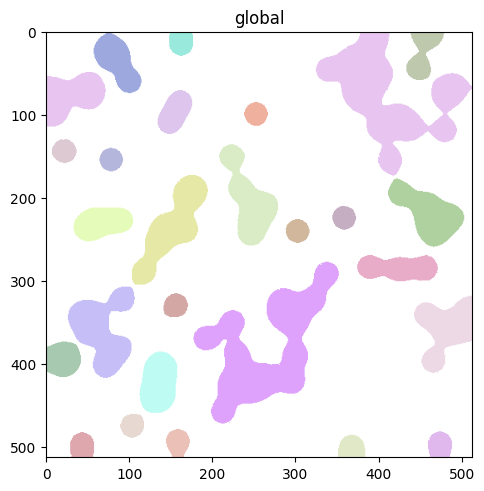

In [9]:
sdata.pl.render_labels('blobs_labels').pl.show()

## 9. Translucent masks over an image — `fill_alpha`

Lowering `fill_alpha` below its `0.4` default lets more of the underlying image show through — the standard way to overlay a
segmentation on the raw data. We layer the labels on top of `blobs_image`.

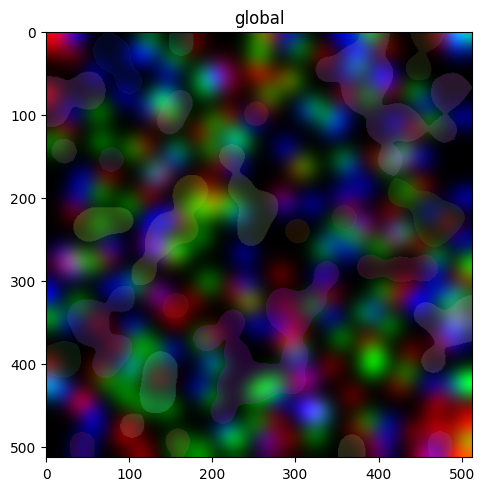

In [10]:
(
    sdata.pl.render_images('blobs_image')
    .pl.render_labels('blobs_labels', fill_alpha=0.2)
).pl.show()

## 10. Segmentation boundaries — `outline` and `contour_px`

For labels, `outline=True` traces each mask's boundary. `contour_px` sets the boundary thickness in
pixels, and `outline_color`/`outline_alpha` style it. Set `fill_alpha=0.0` to show the boundaries
alone.

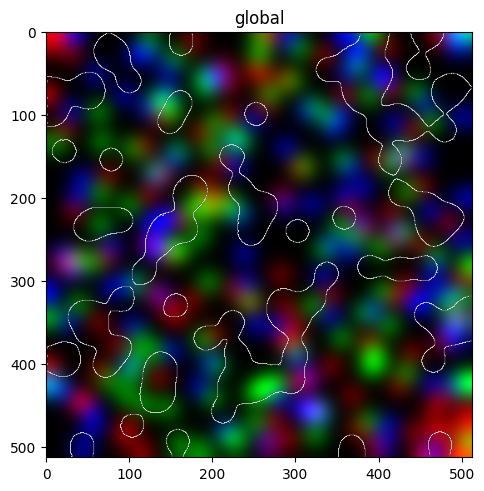

In [11]:
(
    sdata.pl.render_images('blobs_image')
    .pl.render_labels(
        'blobs_labels',
        fill_alpha=0.0,
        outline=True,
        contour_px=3,
        outline_color='white',
    )
).pl.show()

## 11. Putting it together

A translucent fill plus a crisp boundary over the image gives a readable segmentation overlay — the
combination you will reach for most often.

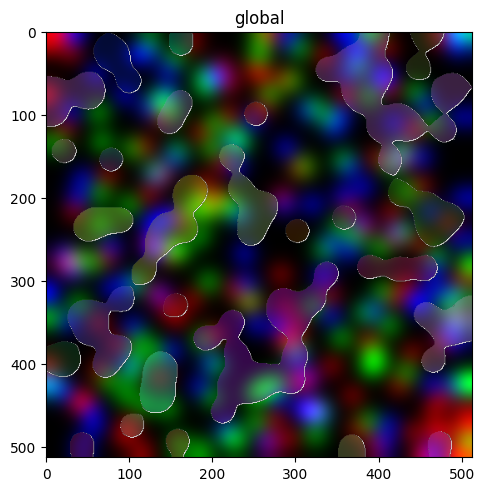

In [12]:
(
    sdata.pl.render_images('blobs_image')
    .pl.render_labels(
        'blobs_labels',
        fill_alpha=0.3,
        outline=True,
        contour_px=2,
        outline_color='white',
        outline_alpha=1.0,
    )
).pl.show()

## Summary

- `fill_alpha` sets fill opacity for both shapes and labels.
- `outline=True` adds a border for shapes and labels; style it with `outline_width`,
  `outline_color`, and `outline_alpha`, and for labels set the boundary thickness with `contour_px`.
- Pass a two-tuple to `outline_width`/`outline_color`/`outline_alpha` for a double outline
  (outer + inner).
- `outline_color` also accepts a column name when the element is annotated by a table, colouring
  each border per shape — see the *Colouring* tutorial.
- A transparent fill plus an outline gives hollow shapes or boundary-only segmentation overlays.
- `scale` resizes shape geometries about their centroids.

## For reproducibility

In [13]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,matplotlib,numpy,pandas

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.4.2
matplotlib      : 3.10.9
numpy           : 2.4.4
pandas          : 2.3.3

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

